In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
plt.style.use("default")
plt.rcParams["figure.figsize"] = (7 , 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.20
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 10
X , y = make_classification(n_samples = 300 , n_features = 2 , n_redundant = 0 ,
                            n_informative = 2 , n_clusters_per_class = 1 ,
                            class_sep = 1.5 , flip_y = 0.03 , random_state = 42)
model = Pipeline([("scaler" , StandardScaler()) ,
 ("clf" , LogisticRegression(max_iter = 2000))])
model.fit(X , y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=2000))])

In [3]:
y_pred = model.predict(X)
y_prob = model.predict_proba(X)[ : , 1]
baseline_acc = accuracy_score(y , y_pred)
avg_confidence = np.mean(np.maximum(y_prob , 1 - y_prob))
print("Week 8 baseline")
print(f"Training accuracy: {baseline_acc:.3f}")
print(f"Average confidence: {avg_confidence:.3f}")
x_min , x_max = X[ : , 0].min() - 1.0 , X[ : , 0].max() + 1.0
y_min , y_max = X[ : , 1].min() - 1.0 , X[ : , 1].max() + 1.0
xx , yy = np.meshgrid(np.linspace(x_min , x_max , 400) ,
                      np.linspace(y_min , y_max , 400))
grid = np.c_[xx.ravel() , yy.ravel()]
Z_pred = model.predict(grid).reshape(xx.shape)
Z_prob = model.predict_proba(grid)[ : , 1].reshape(xx.shape)
Z_score = model.decision_function(grid).reshape(xx.shape)

Week 8 baseline
Training accuracy: 0.957
Average confidence: 0.926


Text(0.5, 1.0, 'Week 8 Toy Dataset')

Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

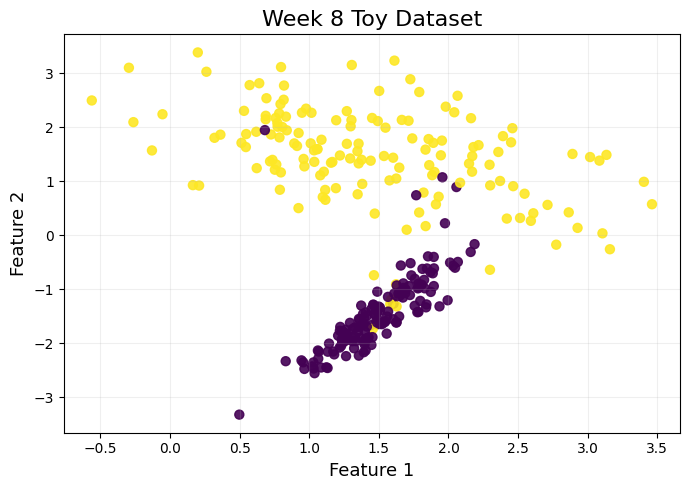

In [4]:
fig , ax = plt.subplots()
ax.scatter(X[ : , 0] , X[ : , 1] , c = y , s = 42 , alpha = 0.90)
ax.set_title("Week 8 Toy Dataset")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
fig.tight_layout()
plt.show()

Text(0.5, 1.0, 'Baseline Decision Boundary (Logistic Regression)')

Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

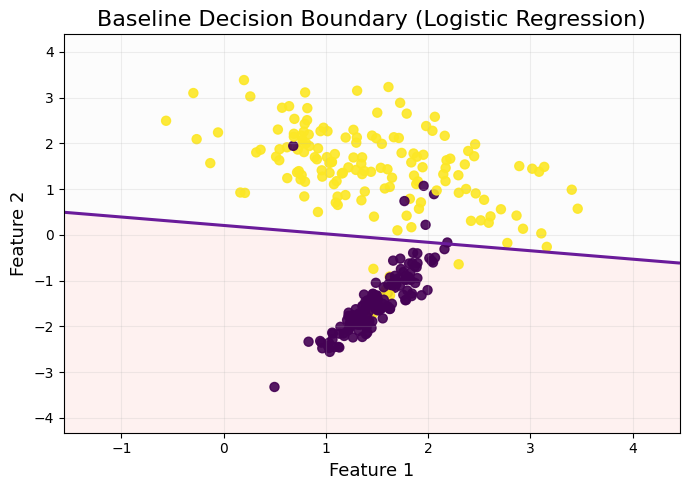

In [5]:
fig , ax = plt.subplots()
ax.contourf(xx , yy , Z_pred , alpha = 0.18 , cmap = plt.cm.Pastel1)
ax.contour(xx , yy , Z_prob , levels = [0.5] , colors = "#6A1B9A" , linewidths = 2.2)
ax.scatter(X[ : , 0] , X[ : , 1] , c = y , s = 42 , alpha = 0.90)
ax.set_title("Baseline Decision Boundary (Logistic Regression)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
fig.tight_layout()
plt.show()

Text(0.5, 1.0, 'Classifier Confidence Surface')

Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

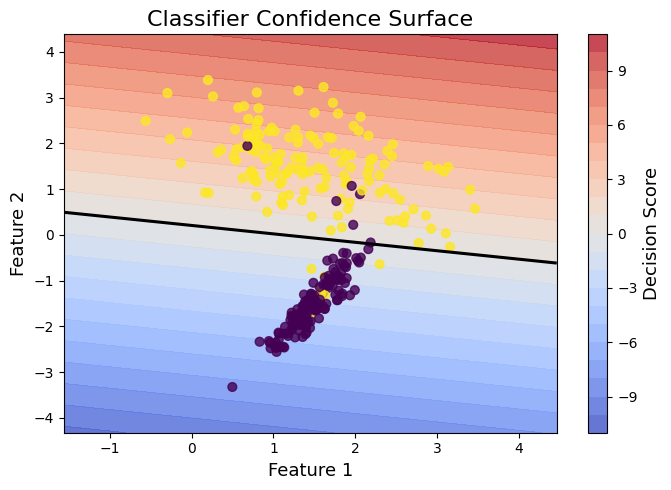

In [6]:
fig , ax = plt.subplots()
ax.grid(False)
score_contour = ax.contourf(xx , yy , Z_score , levels = 20 , alpha = 0.80 ,
                            cmap = "coolwarm")
ax.contour(xx , yy , Z_score , levels = [0] , colors = "black" , linewidths = 2.2)
ax.scatter(X[ : , 0] , X[ : , 1] , c = y , s = 40 , alpha = 0.80)
cbar = fig.colorbar(score_contour)
cbar.set_label("Decision Score")
ax.set_title("Classifier Confidence Surface")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
fig.tight_layout()
plt.show()

Text(0.5, 1.0, 'Probability Surface (Logistic Regression)')

Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

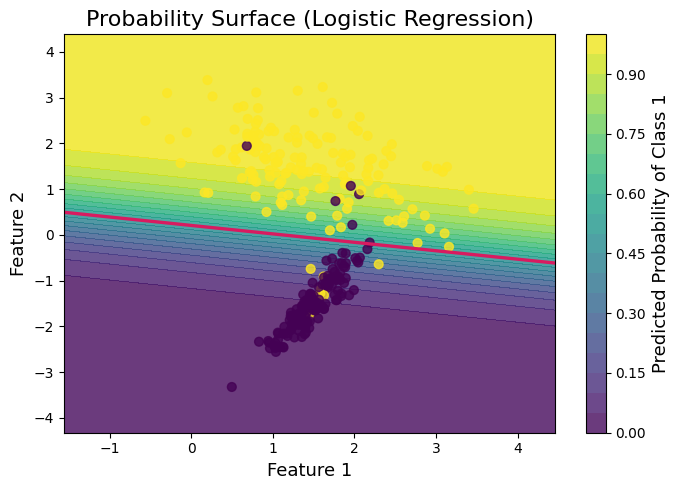

In [7]:
fig , ax = plt.subplots()
ax.grid(False)
prob_contour = ax.contourf(xx , yy , Z_prob , levels = 20 , alpha = 0.80 ,
                           cmap = "viridis")
ax.contour(xx , yy , Z_prob , levels = [0.5] , colors = "#D81B60" , linewidths = 2.4)
ax.scatter(X[ : , 0] , X[ : , 1] , c = y , s = 40 , alpha = 0.80)
cbar = fig.colorbar(prob_contour)
cbar.set_label("Predicted Probability of Class 1")
ax.set_title("Probability Surface (Logistic Regression)")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
fig.tight_layout()
plt.show()

Text(0.5, 1.0, 'Boundary + Margin-Style Bands')

Text(0.5, 0, 'Feature 1')

Text(0, 0.5, 'Feature 2')

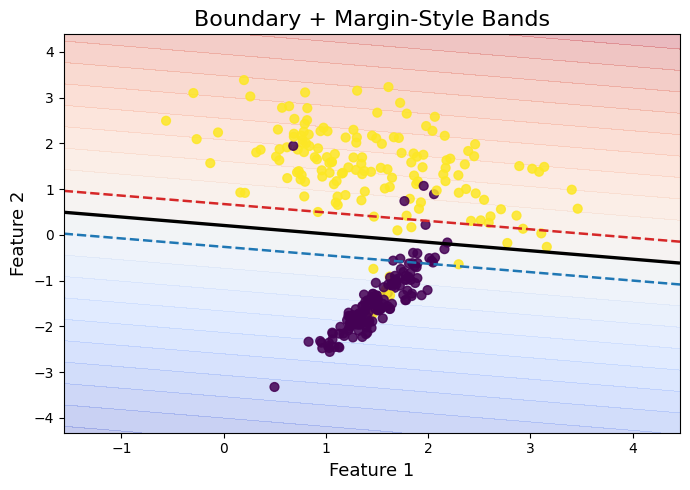

In [8]:
fig , ax = plt.subplots()
ax.grid(False)
band_contour = ax.contourf(xx , yy , Z_score , levels = 25 , alpha = 0.30 ,
                           cmap = "coolwarm")
ax.contour(xx , yy , Z_score , levels = [-1 , 0 , 1] ,
           colors = ["#1f77b4" , "black" , "#d62728"] ,
           linewidths = [1.8 , 2.4 , 1.8] , linestyles = ["--" , "-" , "--"])
ax.scatter(X[ : , 0] , X[ : , 1] , c = y , s = 40 , alpha = 0.85)
ax.set_title("Boundary + Margin-Style Bands")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
fig.tight_layout()
plt.show()